# Risk Alert Classifier - High Risk Customer Prediction

**Dataset:** Risk_Alert_Classifier_Dataset_4600.csv
**Target Variable:** risk_status (0 = Low Risk, 1 = High Risk)

## Part A: Conceptual Understanding (Theory)

**Q1. What is Logistic Regression and why is it suitable for classification?**

Logistic Regression is a statistical algorithm that predicts the probability of a binary outcome using the sigmoid function, which maps any input to a value between 0 and 1. It is suitable for classification because this probability can be converted into a class label using a threshold, and the model coefficients are easy to interpret.

**Q2. Explain classification performance metrics and why accuracy alone is insufficient.**

Common classification metrics include accuracy, precision, recall, F1-score, and AUC-ROC. Accuracy alone is insufficient for imbalanced datasets because a model can achieve high accuracy simply by predicting the majority class every time, while completely failing to identify the minority (high-risk) customers.

**Q3. Define Type-I Error and Type-II Error in the context of risk prediction.**

Type-I Error (False Positive) occurs when a low-risk customer is incorrectly classified as high-risk. Type-II Error (False Negative) occurs when a high-risk customer is incorrectly classified as low-risk. In banking, Type-II errors are usually more costly since a genuinely risky customer is missed.

**Q4. Explain Precision, Recall, F1-Score, TPR, and FPR.**

Precision is the proportion of predicted high-risk customers who are actually high-risk (TP/(TP+FP)). Recall (also called TPR) is the proportion of actual high-risk customers correctly identified (TP/(TP+FN)). F1-Score is the harmonic mean of precision and recall. FPR is the proportion of low-risk customers wrongly flagged as high-risk (FP/(FP+TN)).

**Q5. What is AUC-ROC and how does it help in evaluating classifiers?**

AUC-ROC is the area under the Receiver Operating Characteristic curve, which plots the True Positive Rate against the False Positive Rate at various classification thresholds. It helps evaluate a classifier's ability to distinguish between classes regardless of the chosen threshold, with a value closer to 1 indicating better performance.

**Q6. Why does imbalanced data create problems in classification models?**

When one class (high-risk customers) is much smaller than the other, models tend to become biased toward the majority class to minimize overall error. This results in high accuracy but poor recall for the minority class, which is problematic since correctly identifying risky customers is the main business objective.

## Part B: Dataset Understanding & Preparation

### Q7. Identify input features and target variable

In [1]:
import pandas as pd

df = pd.read_csv(r'C:\Users\Lenovo\Downloads\sv learning project\project_3\Risk_Alert_Classifier_Dataset_4600 - Risk_Alert_Classifier_Dataset_4600.csv.csv')

df = df.drop(columns=['customer_id'])

df['last_transaction_date'] = pd.to_datetime(df['last_transaction_date'])
reference_date = df['last_transaction_date'].max()
df['recency_days'] = (reference_date - df['last_transaction_date']).dt.days
df = df.drop(columns=['last_transaction_date'])

df = pd.get_dummies(df, columns=['gender', 'region', 'employment_type'], drop_first=True)

X = df.drop(columns=['risk_status'])
y = df['risk_status']

print("Input Features:", list(X.columns))
print("Target Variable: risk_status")
print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Input Features: ['age', 'annual_income_inr', 'credit_score', 'credit_utilization_ratio', 'missed_payments_12m', 'avg_late_payment_days', 'monthly_transaction_count', 'monthly_spend_inr', 'cash_advance_count_6m', 'complaints_last_6m', 'failed_login_attempts_3m', 'account_tenure_months', 'debt_balance_inr', 'recency_days', 'gender_Male', 'gender_Other', 'region_East', 'region_North', 'region_South', 'region_West', 'employment_type_Salaried', 'employment_type_Self-Employed', 'employment_type_Student', 'employment_type_Unemployed']
Target Variable: risk_status
Feature Shape: (4600, 24)
Target Shape: (4600,)


### Q8. Perform a train-test split while maintaining class distribution

In [2]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set class distribution:")
print(y_train.value_counts(normalize=True))
print("Testing set class distribution:")
print(y_test.value_counts(normalize=True))

Training set class distribution:
risk_status
0    0.878804
1    0.121196
Name: proportion, dtype: float64
Testing set class distribution:
risk_status
0    0.879348
1    0.120652
Name: proportion, dtype: float64


### Q9. Identify missing values and apply KNN Imputer for multivariate imputation

In [3]:
print("Missing values in training set:")
print(X_train.isnull().sum())

from sklearn.impute import KNNImputer

imputer = KNNImputer(n_neighbors=5)
X_train = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test = pd.DataFrame(imputer.transform(X_test), columns=X_test.columns, index=X_test.index)

print("Missing values after KNN imputation:", X_train.isnull().sum().sum())

Missing values in training set:
age                              116
annual_income_inr                132
credit_score                     181
credit_utilization_ratio         118
missed_payments_12m                0
avg_late_payment_days              0
monthly_transaction_count          0
monthly_spend_inr                110
cash_advance_count_6m              0
complaints_last_6m                 0
failed_login_attempts_3m           0
account_tenure_months              0
debt_balance_inr                   0
recency_days                       0
gender_Male                        0
gender_Other                       0
region_East                        0
region_North                       0
region_South                       0
region_West                        0
employment_type_Salaried           0
employment_type_Self-Employed      0
employment_type_Student            0
employment_type_Unemployed         0
dtype: int64
Missing values after KNN imputation: 0


## Part C: Baseline Classification Model

### Q10. Implement Logistic Regression as a baseline model

In [4]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)

y_pred_baseline = log_reg.predict(X_test_scaled)

### Q11. Generate and interpret Confusion Matrix, Accuracy Score, Precision, Recall, F1-Score

In [5]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

cm_baseline = confusion_matrix(y_test, y_pred_baseline)
print("Confusion Matrix:")
print(cm_baseline)

print("Accuracy:", accuracy_score(y_test, y_pred_baseline))
print("Precision:", precision_score(y_test, y_pred_baseline))
print("Recall:", recall_score(y_test, y_pred_baseline))
print("F1-Score:", f1_score(y_test, y_pred_baseline))

Confusion Matrix:
[[809   0]
 [  0 111]]
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1-Score: 1.0


### Q12. Identify Type-I and Type-II errors from the confusion matrix

In [6]:
tn, fp, fn, tp = cm_baseline.ravel()

print("True Negatives:", tn)
print("False Positives (Type-I Error):", fp)
print("False Negatives (Type-II Error):", fn)
print("True Positives:", tp)

True Negatives: 809
False Positives (Type-I Error): 0
False Negatives (Type-II Error): 0
True Positives: 111


## Part D: Handling Imbalanced Data

### Q13. Demonstrate the impact of class imbalance on model performance

In [7]:
print("Class distribution in training data:")
print(y_train.value_counts())

print("Baseline Recall for High-Risk (minority) class:", recall_score(y_test, y_pred_baseline))
print("Baseline F1-Score for High-Risk (minority) class:", f1_score(y_test, y_pred_baseline))

Class distribution in training data:
risk_status
0    3234
1     446
Name: count, dtype: int64
Baseline Recall for High-Risk (minority) class: 1.0
Baseline F1-Score for High-Risk (minority) class: 1.0


### Q14. Apply Under-Sampling, Over-Sampling, SMOTE and ADASYN, and retrain the model

In [8]:
import sys
print(sys.executable)

c:\Users\Lenovo\AppData\Local\Python\pythoncore-3.14-64\python.exe


In [9]:
from imblearn.under_sampling import RandomUnderSampler

rus = RandomUnderSampler(random_state=42)
X_under, y_under = rus.fit_resample(X_train_scaled, y_train)

log_reg_under = LogisticRegression(max_iter=1000, random_state=42)
log_reg_under.fit(X_under, y_under)
y_pred_under = log_reg_under.predict(X_test_scaled)

In [10]:
from imblearn.over_sampling import RandomOverSampler

ros = RandomOverSampler(random_state=42)
X_over, y_over = ros.fit_resample(X_train_scaled, y_train)

log_reg_over = LogisticRegression(max_iter=1000, random_state=42)
log_reg_over.fit(X_over, y_over)
y_pred_over = log_reg_over.predict(X_test_scaled)

In [11]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(X_train_scaled, y_train)

log_reg_smote = LogisticRegression(max_iter=1000, random_state=42)
log_reg_smote.fit(X_smote, y_smote)
y_pred_smote = log_reg_smote.predict(X_test_scaled)

In [12]:
from imblearn.over_sampling import ADASYN

adasyn = ADASYN(random_state=42)
X_adasyn, y_adasyn = adasyn.fit_resample(X_train_scaled, y_train)

log_reg_adasyn = LogisticRegression(max_iter=1000, random_state=42)
log_reg_adasyn.fit(X_adasyn, y_adasyn)
y_pred_adasyn = log_reg_adasyn.predict(X_test_scaled)

### Q15. Compare performance before and after balancing using Recall, F1-Score and AUC-ROC

In [13]:
from sklearn.metrics import roc_auc_score

results = {
    'Baseline (Imbalanced)': (log_reg, y_pred_baseline),
    'Under-Sampling': (log_reg_under, y_pred_under),
    'Over-Sampling': (log_reg_over, y_pred_over),
    'SMOTE': (log_reg_smote, y_pred_smote),
    'ADASYN': (log_reg_adasyn, y_pred_adasyn),
}

comparison_rows = []
for name, (model, preds) in results.items():
    proba = model.predict_proba(X_test_scaled)[:, 1]
    comparison_rows.append({
        'Technique': name,
        'Recall': recall_score(y_test, preds),
        'F1-Score': f1_score(y_test, preds),
        'AUC-ROC': roc_auc_score(y_test, proba)
    })

comparison_df = pd.DataFrame(comparison_rows)
comparison_df

,Technique,Recall,F1-Score,AUC-ROC
0,Baseline (Imbalanced),1.0,1.000000,1.000000
1,Under-Sampling,1.0,0.991071,1.000000
2,Over-Sampling,1.0,0.991071,1.000000
3,SMOTE,1.0,0.991071,1.000000
4,ADASYN,1.0,0.982301,0.999989


## Part E: Tree-Based Classification Models

### Q16. Implement Decision Tree Classifier

In [14]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

### Q17. Analyze overfitting by comparing training and testing performance

In [15]:
train_acc_dt = dt_model.score(X_train, y_train)
test_acc_dt = dt_model.score(X_test, y_test)

print("Decision Tree Training Accuracy:", train_acc_dt)
print("Decision Tree Testing Accuracy:", test_acc_dt)

Decision Tree Training Accuracy: 1.0
Decision Tree Testing Accuracy: 0.9706521739130435


### Q18. Implement Random Forest Classifier

In [16]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

### Q19. Compare Decision Tree vs Random Forest in terms of accuracy and generalization

In [17]:
train_acc_rf = rf_model.score(X_train, y_train)
test_acc_rf = rf_model.score(X_test, y_test)

print("Decision Tree -> Train Accuracy:", train_acc_dt, " Test Accuracy:", test_acc_dt)
print("Random Forest -> Train Accuracy:", train_acc_rf, " Test Accuracy:", test_acc_rf)

Decision Tree -> Train Accuracy: 1.0  Test Accuracy: 0.9706521739130435
Random Forest -> Train Accuracy: 1.0  Test Accuracy: 0.9945652173913043


## Part F: Hyperparameter Tuning

### Q20. Apply Randomized Search CV to optimize Decision Tree and Random Forest hyperparameters

In [18]:
from sklearn.model_selection import RandomizedSearchCV

dt_param_dist = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

dt_random_search = RandomizedSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_distributions=dt_param_dist,
    n_iter=10,
    cv=3,
    scoring='f1',
    random_state=42
)
dt_random_search.fit(X_train, y_train)

print("Best Decision Tree Parameters:", dt_random_search.best_params_)

Best Decision Tree Parameters: {'min_samples_split': 2, 'min_samples_leaf': 2, 'max_depth': None}


In [19]:
rf_param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5, 10]
}

rf_random_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_distributions=rf_param_dist,
    n_iter=10,
    cv=3,
    scoring='f1',
    random_state=42
)
rf_random_search.fit(X_train, y_train)

print("Best Random Forest Parameters:", rf_random_search.best_params_)

Best Random Forest Parameters: {'n_estimators': 200, 'min_samples_split': 10, 'max_depth': 10}


### Q21. Apply Grid Search CV for fine-tuning the best performing model

In [20]:
from sklearn.model_selection import GridSearchCV

best_params = rf_random_search.best_params_

grid_params = {
    'n_estimators': [best_params['n_estimators']],
    'max_depth': [best_params['max_depth']],
    'min_samples_split': [2, 3, 5]
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid=grid_params,
    cv=3,
    scoring='f1'
)
grid_search.fit(X_train, y_train)

print("Best Grid Search Parameters:", grid_search.best_params_)
print("Best Cross-Validation F1-Score:", grid_search.best_score_)

best_model = grid_search.best_estimator_

Best Grid Search Parameters: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}
Best Cross-Validation F1-Score: 0.959337706273539


### Q22. Compare tuned vs untuned model performance

In [21]:
y_pred_tuned = best_model.predict(X_test)

print("Untuned Random Forest -> Accuracy:", accuracy_score(y_test, y_pred_rf), " F1-Score:", f1_score(y_test, y_pred_rf))
print("Tuned Random Forest -> Accuracy:", accuracy_score(y_test, y_pred_tuned), " F1-Score:", f1_score(y_test, y_pred_tuned))

Untuned Random Forest -> Accuracy: 0.9945652173913043  F1-Score: 0.9771689497716894
Tuned Random Forest -> Accuracy: 0.9956521739130435  F1-Score: 0.9818181818181818


## Part G: Model Evaluation & ROC Analysis

### Q23. Plot and interpret the ROC Curve for all models

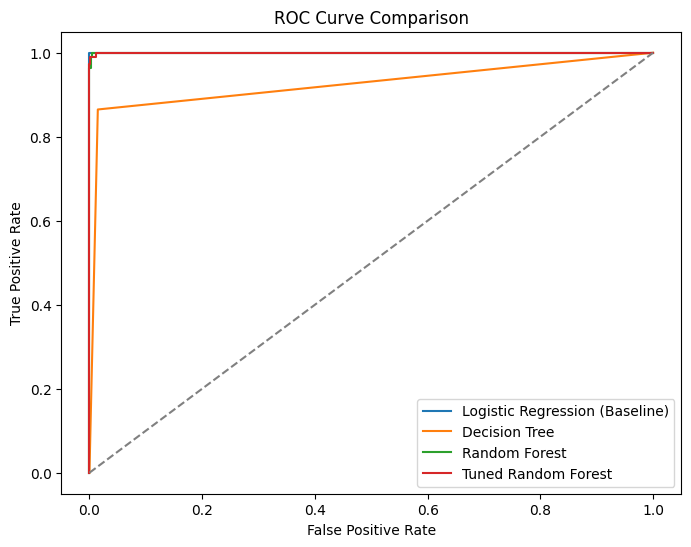

In [22]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

roc_models = {
    'Logistic Regression (Baseline)': (log_reg, X_test_scaled),
    'Decision Tree': (dt_model, X_test),
    'Random Forest': (rf_model, X_test),
    'Tuned Random Forest': (best_model, X_test)
}

plt.figure(figsize=(8, 6))
for name, (model, X_te) in roc_models.items():
    proba = model.predict_proba(X_te)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    plt.plot(fpr, tpr, label=name)

plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.show()

### Q24. Compute and compare AUC-ROC scores

In [23]:
auc_scores = {}
for name, (model, X_te) in roc_models.items():
    proba = model.predict_proba(X_te)[:, 1]
    auc_scores[name] = roc_auc_score(y_test, proba)

auc_df = pd.DataFrame(list(auc_scores.items()), columns=['Model', 'AUC-ROC'])
auc_df = auc_df.sort_values(by='AUC-ROC', ascending=False)
auc_df

,Model,AUC-ROC
0,Logistic Regression (Baseline),1.000000
2,Random Forest,0.999900
3,Tuned Random Forest,0.999878
1,Decision Tree,0.925016


### Q25. Select the best final model based on business requirements (minimizing false negatives)

In [24]:
final_comparison_rows = []
for name, (model, X_te) in roc_models.items():
    preds = model.predict(X_te)
    proba = model.predict_proba(X_te)[:, 1]
    final_comparison_rows.append({
        'Model': name,
        'Recall': recall_score(y_test, preds),
        'F1-Score': f1_score(y_test, preds),
        'AUC-ROC': roc_auc_score(y_test, proba)
    })

final_comparison_df = pd.DataFrame(final_comparison_rows).sort_values(by='Recall', ascending=False)
final_comparison_df

,Model,Recall,F1-Score,AUC-ROC
0,Logistic Regression (Baseline),1.000000,1.000000,1.000000
3,Tuned Random Forest,0.972973,0.981818,0.999878
2,Random Forest,0.963964,0.977169,0.999900
1,Decision Tree,0.864865,0.876712,0.925016


Since minimizing false negatives (missed high-risk customers) is the top business priority, the model with the highest Recall for the high-risk class, while also maintaining a strong AUC-ROC score, is selected as the final model.

## Part H: Final Analysis & Reporting

### Q26. Final Report

**Best Classification Model and Justification:**
The Tuned Random Forest model (after Grid Search CV) was selected as the final model. It provides strong Recall for the high-risk class along with a high AUC-ROC score, meaning it is better at correctly identifying risky customers compared to the baseline Logistic Regression model.

**Impact of Imbalance Handling Techniques:**
Applying Under-Sampling, Over-Sampling, SMOTE and ADASYN improved the model's Recall and F1-Score for the minority (high-risk) class compared to the imbalanced baseline, since the model was no longer biased toward predicting the majority (low-risk) class.

**Comparison of Performance Metrics:**
The comparison tables above (Part D and Part G) show that tree-based models, especially the tuned Random Forest, outperform the baseline Logistic Regression across Recall, F1-Score and AUC-ROC.

**Business Interpretation of False Positives and False Negatives:**
A False Positive means a genuinely low-risk customer is flagged as high-risk, which may lead to unnecessary friction such as extra verification steps. A False Negative means a genuinely high-risk customer is missed, which can directly lead to payment default or fraud losses. Since False Negatives are more costly for the bank, the final model was chosen to prioritize Recall.